<a href="https://colab.research.google.com/github/WaadZiadeh/Spoken-Project/blob/main/Spoken_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Generated Speech Detection

## Course Project - Spoken Language Processing

### Team Members
- Partner 1: Waad Ziadeh 1220423
- Partner 2:
- Partner 3:

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

DATA_DIR = "/content/drive/MyDrive/Spoken_Project"

os.listdir(DATA_DIR)

['dataset', 'code', 'results', 'report']

In [10]:
DATASET_DIR = os.path.join(DATA_DIR, "dataset")

print(os.listdir(DATASET_DIR))

['ASVspoof2021_DF_eval_part00.tar.gz', 'ASVspoof_DF', 'DF-keys-full.tar.gz', 'metadata', 'part00_labels.csv', 'train.csv', 'validation.csv', 'test.csv']


In [11]:
ASVSPOOF_DIR = os.path.join(DATASET_DIR, "ASVspoof_DF")

print(os.listdir(ASVSPOOF_DIR))

['ASVspoof2021_DF_eval']


In [12]:
EVAL_DIR = os.path.join(
    ASVSPOOF_DIR,
    "ASVspoof2021_DF_eval"
)

print(os.listdir(EVAL_DIR))

['ASVspoof2021.DF.cm.eval.trl.txt', 'LICENSE.DF.txt', 'README.DF.txt', 'flac']


In [13]:
import pandas as pd

TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")
VAL_CSV = os.path.join(DATASET_DIR, "validation.csv")
TEST_CSV = os.path.join(DATASET_DIR, "test.csv")

train = pd.read_csv(TRAIN_CSV)
validation = pd.read_csv(VAL_CSV)
test = pd.read_csv(TEST_CSV)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

print(train.head())

Train shape: (7749, 3)
Validation shape: (1660, 3)
Test shape: (1661, 3)
        file_id     label                                         audio_path
0  DF_E_2015148     spoof  /content/drive/MyDrive/Spoken_Project/dataset/...
1  DF_E_2304773     spoof  /content/drive/MyDrive/Spoken_Project/dataset/...
2  DF_E_2362773     spoof  /content/drive/MyDrive/Spoken_Project/dataset/...
3  DF_E_2159994  bonafide  /content/drive/MyDrive/Spoken_Project/dataset/...
4  DF_E_2276883  bonafide  /content/drive/MyDrive/Spoken_Project/dataset/...


In [14]:
import os

audio_path = train.iloc[0]["audio_path"]

print("Path:", audio_path)
print("Exists:", os.path.exists(audio_path))
print("File size:", os.path.getsize(audio_path) if os.path.exists(audio_path) else "File not found")

Path: /content/drive/MyDrive/Spoken_Project/dataset/ASVspoof_DF/ASVspoof2021_DF_eval/flac/DF_E_2015148.flac
Exists: True
File size: 29496


#**Dataset preprocessing**

## Audio Preprocessing

The audio preprocessing stage prepares the raw speech recordings for feature extraction and classification. Since the ASVspoof 2021 DF recordings are already provided as mono audio with a sampling rate of 16 kHz, the preprocessing focuses on standardizing the audio representation while preserving important acoustic characteristics.

### Preprocessing Steps

1. **Load the Audio**
   - Load each `.flac` audio file from its corresponding `audio_path`.
   - Convert the audio file into a numerical waveform that can be processed by the machine learning pipeline.

2. **Convert to Mono**
   - Convert the audio signal to a single channel.
   - This ensures that all recordings have the same channel configuration.
   - The dataset is already provided as mono, so no major transformation is required for the current recordings.

3. **Resample to 16 kHz**
   - Standardize the sampling rate of all audio recordings to **16,000 Hz**.
   - The ASVspoof 2021 DF recordings used in this project are already sampled at 16 kHz.
   - Keeping a consistent sampling rate ensures that the extracted acoustic features are calculated using the same time-frequency resolution.

4. **Convert to Float32**
   - Convert the audio samples to the `float32` data type.
   - This provides a consistent numerical representation for subsequent audio processing and feature extraction.

5. **Amplitude Normalization**
   - Normalize the amplitude of each audio signal.
   - The waveform is scaled so that its maximum absolute amplitude is approximately within the range `[-1, 1]`.
   - This reduces variations in signal scale between recordings while preserving the main acoustic characteristics.

### Preprocessing Pipeline

**Raw FLAC Audio → Load Audio → Mono → 16 kHz → Float32 → Amplitude Normalization → Preprocessed Audio**

The resulting preprocessed audio signals are then passed to the feature extraction stage, where acoustic features such as MFCCs can be extracted for classification.

In [15]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

In [16]:
TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")
VAL_CSV = os.path.join(DATASET_DIR, "validation.csv")
TEST_CSV = os.path.join(DATASET_DIR, "test.csv")

In [17]:
train = pd.read_csv(TRAIN_CSV)
validation = pd.read_csv(VAL_CSV)
test = pd.read_csv(TEST_CSV)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (7749, 3)
Validation: (1660, 3)
Test: (1661, 3)


In [18]:
TARGET_SR = 16000

def preprocess_audio(audio_path, target_sr=TARGET_SR):

    # 1. Load audio as mono
    audio, sr = librosa.load(
        audio_path,
        sr=target_sr,
        mono=True
    )

    # 2. Convert to float32
    audio = audio.astype(np.float32)

    # 3. Normalize amplitude
    max_amplitude = np.max(np.abs(audio))

    if max_amplitude > 0:
        audio = audio / max_amplitude

    return audio, target_sr

In [19]:
audio_path = train.iloc[0]["audio_path"]

audio, sr = preprocess_audio(audio_path)

print("File ID:", train.iloc[0]["file_id"])
print("Label:", train.iloc[0]["label"])
print("Sample rate:", sr)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / sr, "seconds")
print("Minimum amplitude:", audio.min())
print("Maximum amplitude:", audio.max())

/tmp/ipykernel_6023/3803642878.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File ID: DF_E_2015148
Label: spoof
Sample rate: 16000
Number of samples: 24081
Duration: 1.5050625 seconds
Minimum amplitude: -1.0
Maximum amplitude: 0.78707886


In [20]:
print("Audio dtype:", audio.dtype)
print("Audio range:", audio.min(), "to", audio.max())
print("Has NaN:", np.isnan(audio).any())
print("Has Inf:", np.isinf(audio).any())

Audio dtype: float32
Audio range: -1.0 to 0.78707886
Has NaN: False
Has Inf: False


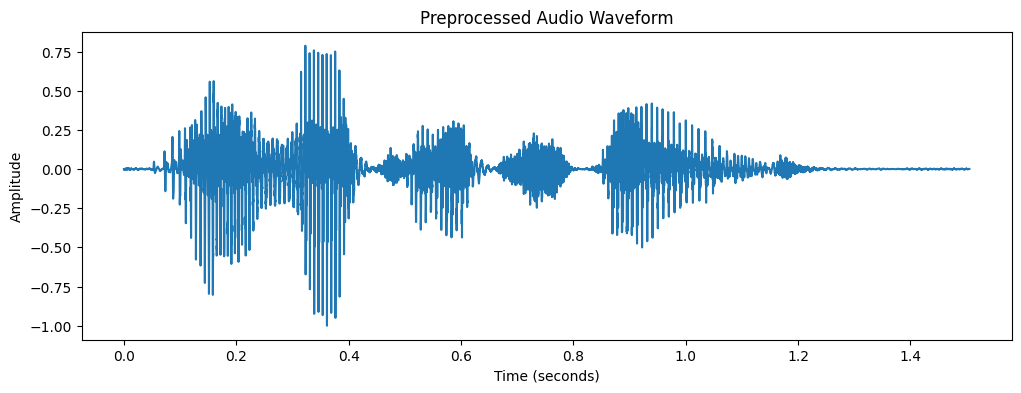

In [21]:
time = np.arange(len(audio)) / sr

plt.figure(figsize=(12, 4))
plt.plot(time, audio)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Preprocessed Audio Waveform")

plt.show()

In [22]:
def preprocess_row(row):
    audio, sr = preprocess_audio(row["audio_path"])
    return audio, sr

audio, sr = preprocess_row(train.iloc[10])

print("File ID:", train.iloc[10]["file_id"])
print("Label:", train.iloc[10]["label"])
print("Duration:", len(audio) / sr)

File ID: DF_E_2411282
Label: bonafide
Duration: 4.5656875


In [23]:
def preprocess_audio_safe(audio_path, target_sr=TARGET_SR):
    try:
        # Load as mono and resample to target sample rate
        audio, sr = librosa.load(
            audio_path,
            sr=target_sr,
            mono=True
        )

        # Convert to float32
        audio = audio.astype(np.float32)

        # Check for empty audio
        if len(audio) == 0:
            return None

        # Check for invalid values
        if np.isnan(audio).any() or np.isinf(audio).any():
            return None

        # Normalize amplitude
        max_amplitude = np.max(np.abs(audio))

        if max_amplitude > 0:
            audio = audio / max_amplitude

        return audio

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

In [24]:
for i in range(5):

    path = train.iloc[i]["audio_path"]
    audio = preprocess_audio_safe(path)

    print(
        train.iloc[i]["file_id"],
        "|",
        train.iloc[i]["label"],
        "|",
        "Success" if audio is not None else "Failed"
    )

/tmp/ipykernel_6023/3521638027.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


DF_E_2015148 | spoof | Success
DF_E_2304773 | spoof | Success
DF_E_2362773 | spoof | Success


/tmp/ipykernel_6023/3521638027.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


DF_E_2159994 | bonafide | Success
DF_E_2276883 | bonafide | Success


In [25]:
def check_audio_files(df, name):

    missing = 0
    failed = 0

    for path in df["audio_path"]:

        if not os.path.exists(path):
            missing += 1
            continue

        try:
            audio, sr = librosa.load(
                path,
                sr=TARGET_SR,
                mono=True
            )

            if len(audio) == 0:
                failed += 1

        except Exception:
            failed += 1

    print(f"{name}:")
    print("Total:", len(df))
    print("Missing:", missing)
    print("Failed to read:", failed)

#**MFCC + SVM**

#**LFCC + SVM**

Preprocessing → LFCC Extraction → Feature Preparation → SVM → Tuning → Evaluation → Save Results

## Step 1: LFCC Feature Extraction

First, we extract **Linear Frequency Cepstral Coefficients (LFCCs)** from the preprocessed speech signals.

LFCCs are features that describe the important characteristics of speech as numbers. These features will be used as input for the **SVM classifier**.

Unlike **MFCCs**, which use a **Mel-scaled filter bank**, LFCCs use a **linear filter bank**.

The LFCC extraction process includes:

1. **STFT:** "Short-Time Fourier Transform" Divide the speech signal into small frames and analyze the frequencies.
2. **Power Spectrum:** Calculate the power of the frequencies.
3. **Linear Filter Bank:** Apply filters that are evenly spaced in frequency.
4. **Logarithm:** Calculate the logarithm of the filter-bank energies.
5. **DCT:** Apply the Discrete Cosine Transform to get the cepstral coefficients.
6. **Select LFCCs:** Select the required number of LFCC coefficients.

Finally, the LFCC features are converted into a **fixed-size representation** so they can be used by the **SVM classifier**.


In [26]:
import numpy as np
import librosa
import scipy.fftpack
import matplotlib.pyplot as plt

N_LFCC = 13
N_FFT = 512
HOP_LENGTH = 256
N_FILTERS = 40

### 1.1 Create a Linear Filter Bank

LFCCs use a **Linear Filter Bank** to analyze the frequencies in the speech signal.

The filter bank contains several **triangular filters** to capture enough frequency information while keeping the feature representation manageable.. Each filter looks at a specific range of frequencies and measures the **energy** in that range.

In our project, we use **40 filters**. The filters are evenly spaced from **0 Hz** to the **Nyquist frequency**, which is half of the sampling rate.

The filters also **overlap** with each other.


In [27]:
def linear_filter_bank(
    sr,
    n_fft,
    n_filters,
    fmin=0,
    fmax=None
):
    if fmax is None:
        fmax = sr / 2

    # Frequency bins produced by the FFT
    freqs = np.linspace(
        0,
        sr / 2,
        n_fft // 2 + 1
    )

    # Linearly spaced filter points
    filter_points = np.linspace(
        fmin,
        fmax,
        n_filters + 2
    )

    # Initialize the filter bank
    filter_bank = np.zeros(
        (n_filters, len(freqs))
    )

    for i in range(n_filters):

        left = filter_points[i]
        center = filter_points[i + 1]
        right = filter_points[i + 2]

        # Rising part of the triangular filter
        left_slope = (freqs - left) / (center - left)

        # Falling part of the triangular filter
        right_slope = (right - freqs) / (right - center)

        # Construct the triangular filter
        filter_bank[i] = np.maximum(
            0,
            np.minimum(left_slope, right_slope)
        )

    return filter_bank

### 1.2 Extract LFCC Features

After creating the linear filter bank, the preprocessed audio signal is converted into LFCC features.

The audio is first transformed into the frequency domain using STFT. The power spectrum is then calculated and passed through the linear filter bank. The logarithm of the filter-bank energies is computed, followed by the Discrete Cosine Transform (DCT).

The first 13 coefficients are selected as the LFCC representation.

In [28]:
def extract_lfcc(
    audio_path,
    n_lfcc=N_LFCC,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_filters=N_FILTERS
):

    # Load and preprocess the audio
    audio, sr = preprocess_audio(audio_path)

    # Compute Short-Time Fourier Transform
    stft = librosa.stft(
        audio,
        n_fft=n_fft,
        hop_length=hop_length
    )

    # Calculate magnitude spectrum
    magnitude = np.abs(stft)

    # Calculate power spectrum
    power_spectrum = magnitude ** 2

    # Create the linear filter bank
    filter_bank = linear_filter_bank(
        sr=sr,
        n_fft=n_fft,
        n_filters=n_filters
    )

    # Apply the filter bank
    filter_energies = np.dot(
        filter_bank,
        power_spectrum
    )

    # Avoid log(0)
    filter_energies = np.maximum(
        filter_energies,
        1e-10
    )

    # Convert energies to logarithmic scale
    log_energies = np.log(
        filter_energies
    )

    # Apply Discrete Cosine Transform
    lfcc = scipy.fftpack.dct(
        log_energies,
        type=2,
        axis=0,
        norm="ortho"
    )

    # Keep the first 13 LFCC coefficients
    lfcc = lfcc[:n_lfcc, :]

    return lfcc, sr

### 1.3 Test LFCC Extraction

Before extracting LFCCs from the complete dataset, the extraction function is tested on a single audio file.

This allows us to verify that the preprocessing and LFCC extraction steps work correctly before processing the full dataset.

In [29]:
audio_path = train.iloc[0]["audio_path"]

lfcc, sr = extract_lfcc(audio_path)

print("File ID:", train.iloc[0]["file_id"])
print("Label:", train.iloc[0]["label"])
print("Sample Rate:", sr)
print("LFCC Shape:", lfcc.shape)

File ID: DF_E_2015148
Label: spoof
Sample Rate: 16000
LFCC Shape: (13, 95)


/tmp/ipykernel_6023/3803642878.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


### Step 1 Summary

The LFCC extraction process was successfully applied to a sample audio recording.

For the tested file:

- **File ID:** DF_E_2015148
- **Label:** Spoof
- **Sample Rate:** 16 kHz
- **LFCC Shape:** (13, 95)

The resulting LFCC representation contains **13 LFCC coefficients across 95 time frames**.

The extraction pipeline consisted of:

**Preprocessing → STFT → Power Spectrum → Linear Filter Bank → Log Energies → DCT → 13 LFCC Coefficients**

The LFCC features are now ready for the next stage, where they will be converted into a fixed-size feature representation suitable for the SVM classifier.

### 1.4 LFCC Visualization

The extracted LFCC features are visualized as a time-frequency representation.

The horizontal axis represents the time frames, while the vertical axis represents the LFCC coefficients.

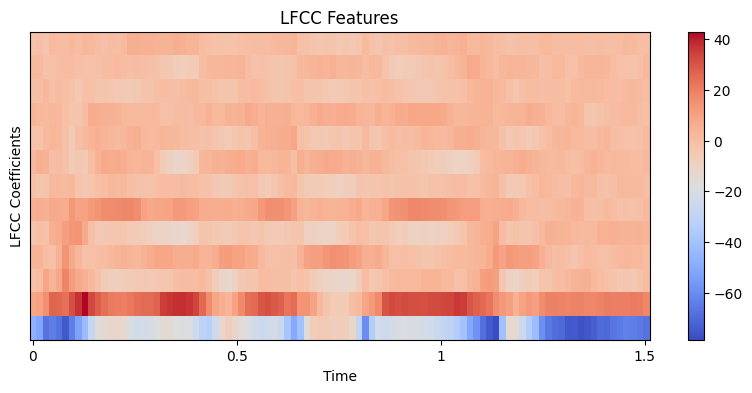

In [30]:
import librosa.display

plt.figure(figsize=(10, 4))

librosa.display.specshow(
    lfcc,
    x_axis="time",
    sr=sr,
    hop_length=HOP_LENGTH
)

plt.colorbar()
plt.title("LFCC Features")
plt.xlabel("Time")
plt.ylabel("LFCC Coefficients")

plt.show()

## Step 2: LFCC Feature Preparation

The extracted LFCC features have a variable number of time frames because the speech recordings have different durations.

To use LFCCs as input to the SVM classifier, each recording must be represented by a fixed-size feature vector.

For each LFCC coefficient, we calculate statistical summaries across the time frames. In this project, the mean and standard deviation are used to summarize the temporal variation of the LFCC features.

This converts the variable-size LFCC matrix into a fixed-size feature vector for each audio recording.

In [31]:
def prepare_lfcc_features(lfcc):
    # Calculate mean across time frames
    mean_features = np.mean(lfcc, axis=1)

    # Calculate standard deviation across time frames
    std_features = np.std(lfcc, axis=1)

    # Combine mean and standard deviation
    features = np.concatenate([
        mean_features,
        std_features
    ])

    return features

In [32]:
features = prepare_lfcc_features(lfcc)

print("Original LFCC shape:", lfcc.shape)
print("Prepared feature shape:", features.shape)

Original LFCC shape: (13, 95)
Prepared feature shape: (26,)


In [33]:
from tqdm import tqdm

def process_dataset(df):
    features_list = []
    labels_list = []

    for _, row in tqdm(df.iterrows(), total=len(df)):

        try:
            # Extract LFCC
            lfcc, sr = extract_lfcc(row["audio_path"])

            # Convert LFCC matrix to fixed-size vector
            features = prepare_lfcc_features(lfcc)

            features_list.append(features)
            labels_list.append(row["label"])

        except Exception as e:
            print(f"Error processing {row['file_id']}: {e}")

    X = np.array(features_list)
    y = np.array(labels_list)

    return X, y

In [37]:
import subprocess
import numpy as np

TARGET_SR = 16000

def preprocess_audio(audio_path, target_sr=TARGET_SR):

    result = subprocess.run(
        [
            "ffmpeg",
            "-v", "error",
            "-i", audio_path,
            "-f", "f32le",
            "-ac", "1",
            "-ar", str(target_sr),
            "-"
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    if result.returncode != 0:
        raise RuntimeError(result.stderr.decode())

    audio = np.frombuffer(
        result.stdout,
        dtype=np.float32
    )

    # Peak normalization
    max_amplitude = np.max(np.abs(audio))

    if max_amplitude > 0:
        audio = audio / max_amplitude

    return audio, target_sr

In [38]:
audio, sr = preprocess_audio(train.iloc[0]["audio_path"])

print("Sample Rate:", sr)
print("Audio Shape:", audio.shape)
print("Audio Type:", audio.dtype)
print("Max Amplitude:", np.max(np.abs(audio)))

Sample Rate: 16000
Audio Shape: (24081,)
Audio Type: float32
Max Amplitude: 1.0


In [39]:
lfcc, sr = extract_lfcc(train.iloc[0]["audio_path"])

print("LFCC Shape:", lfcc.shape)

LFCC Shape: (13, 95)


In [40]:
features = prepare_lfcc_features(lfcc)

print("Feature Shape:", features.shape)

Feature Shape: (26,)


In [41]:
from tqdm import tqdm

def process_dataset(df):
    features_list = []
    labels_list = []

    for _, row in tqdm(df.iterrows(), total=len(df)):

        try:
            # Extract LFCC
            lfcc, sr = extract_lfcc(row["audio_path"])

            # Convert LFCC to fixed-size vector
            features = prepare_lfcc_features(lfcc)

            features_list.append(features)
            labels_list.append(row["label"])

        except Exception as e:
            print(f"Error processing {row['file_id']}: {e}")

    X = np.array(features_list)
    y = np.array(labels_list)

    return X, y

In [42]:
X_train, y_train = process_dataset(train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

100%|██████████| 7749/7749 [42:16<00:00,  3.06it/s]

X_train shape: (7749, 26)
y_train shape: (7749,)


In [43]:
X_val, y_val = process_dataset(validation)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

100%|██████████| 1660/1660 [11:34<00:00,  2.39it/s]

X_val shape: (1660, 26)
y_val shape: (1660,)


In [44]:
X_test, y_test = process_dataset(test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

100%|██████████| 1661/1661 [11:42<00:00,  2.37it/s]

X_test shape: (1661, 26)
y_test shape: (1661,)


#Step 3: Feature Scaling

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [46]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (7749, 26)
X_val_scaled shape: (1660, 26)
X_test_scaled shape: (1661, 26)


## Step 4: Support Vector Machine (SVM) Classification

After extracting and scaling the LFCC-based features, a Support Vector Machine (SVM) classifier is trained to distinguish between bona fide human speech and spoofed speech.

SVM is a supervised machine learning algorithm that finds a decision boundary that separates the two classes.

In this project:
- Input: 26 scaled LFCC-based features for each audio file.
- Classes: bona fide and spoof.
- Training data: training set only.
- Validation data: used to compare model configurations.
- Test data: used only for the final evaluation.

Different SVM kernels can be evaluated to determine which one performs better for the LFCC features.

In [47]:
from sklearn.svm import SVC

svm_linear = SVC(
    kernel="linear",
    random_state=42
)

svm_linear.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [48]:
y_val_pred_linear = svm_linear.predict(X_val_scaled)

print("Validation predictions shape:", y_val_pred_linear.shape)

Validation predictions shape: (1660,)


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_val, y_val_pred_linear)
precision = precision_score(
    y_val,
    y_val_pred_linear,
    pos_label="spoof"
)
recall = recall_score(
    y_val,
    y_val_pred_linear,
    pos_label="spoof"
)
f1 = f1_score(
    y_val,
    y_val_pred_linear,
    pos_label="spoof"
)

print("Linear SVM - Validation Results")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Linear SVM - Validation Results
Accuracy : 0.7463855421686747
Precision: 0.7386231038506418
Recall   : 0.7626506024096386
F1-score : 0.7504445761707172


Step 4.2 — RBF Kernel

In [50]:
svm_rbf = SVC(
    kernel="rbf",
    random_state=42
)

svm_rbf.fit(X_train_scaled, y_train)

y_val_pred_rbf = svm_rbf.predict(X_val_scaled)

In [51]:
accuracy = accuracy_score(y_val, y_val_pred_rbf)

precision = precision_score(
    y_val,
    y_val_pred_rbf,
    pos_label="spoof"
)

recall = recall_score(
    y_val,
    y_val_pred_rbf,
    pos_label="spoof"
)

f1 = f1_score(
    y_val,
    y_val_pred_rbf,
    pos_label="spoof"
)

print("RBF SVM - Validation Results")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

RBF SVM - Validation Results
Accuracy : 0.8259036144578313
Precision: 0.813441483198146
Recall   : 0.8457831325301205
F1-score : 0.8292971057294743


## Comparison of Linear SVM and RBF SVM

The Linear SVM achieved an accuracy of 74.64%, precision of 73.86%, recall of 76.27%, and F1-score of 75.04% on the validation set. These results show that the linear kernel can distinguish between bona fide and spoof speech reasonably well.

The RBF SVM achieved better results, with an accuracy of 82.59%, precision of 81.34%, recall of 84.58%, and F1-score of 82.93%. The higher performance indicates that the RBF kernel can capture more complex, non-linear relationships between the LFCC-based features and the two speech classes.

Overall, the RBF SVM outperformed the Linear SVM across all evaluation metrics. Therefore, the RBF SVM was selected as the better-performing model for the next stage of the experiment.

| Metric | Linear SVM | RBF SVM |
|---|---:|---:|
| Accuracy | 74.64% | **82.59%** |
| Precision | 73.86% | **81.34%** |
| Recall | 76.27% | **84.58%** |
| F1-score | 75.04% | **82.93%** |

## Step 4.3: Hyperparameter Tuning for RBF SVM

The RBF SVM achieved better validation performance than the Linear SVM. Therefore, hyperparameter tuning is performed to improve the RBF SVM performance.

Two important hyperparameters are considered:

- **C** controls the trade-off between a wider decision boundary and classification errors.
- **Gamma** controls how strongly each training sample influences the decision boundary.

Different combinations of C and gamma are evaluated using the training and validation sets. The validation performance is used to select the best configuration.

The test set is not used during hyperparameter tuning to avoid data leakage.

In [52]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

C_values = [0.1, 1, 10, 100]
gamma_values = ["scale", 0.01, 0.1, 1]

results = []

for C in C_values:
    for gamma in gamma_values:

        svm = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            random_state=42
        )

        svm.fit(X_train_scaled, y_train)

        y_val_pred = svm.predict(X_val_scaled)

        accuracy = accuracy_score(y_val, y_val_pred)
        precision = precision_score(
            y_val,
            y_val_pred,
            pos_label="spoof"
        )
        recall = recall_score(
            y_val,
            y_val_pred,
            pos_label="spoof"
        )
        f1 = f1_score(
            y_val,
            y_val_pred,
            pos_label="spoof"
        )

        results.append({
            "C": C,
            "Gamma": gamma,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

In [53]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,C,Gamma,Accuracy,Precision,Recall,F1
0,0.1,scale,0.783735,0.761376,0.826506,0.792605
1,0.1,0.01,0.762651,0.741685,0.806024,0.772517
2,0.1,0.1,0.784940,0.745078,0.866265,0.801114
3,0.1,1,0.500000,0.500000,1.000000,0.666667
4,1.0,scale,0.825904,0.813441,0.845783,0.829297
5,1.0,0.01,0.786145,0.774566,0.807229,0.790560
6,1.0,0.1,0.860241,0.850939,0.873494,0.862069
7,1.0,1,0.728313,0.649566,0.991566,0.784931
8,10.0,scale,0.874699,0.886816,0.859036,0.872705
9,10.0,0.01,0.821687,0.816351,0.830120,0.823178


In [54]:
results_df.sort_values(
    by="F1",
    ascending=False
)

,C,Gamma,Accuracy,Precision,Recall,F1
10,10.0,0.1,0.874699,0.884901,0.861446,0.873016
8,10.0,scale,0.874699,0.886816,0.859036,0.872705
14,100.0,0.1,0.866265,0.876238,0.853012,0.864469
6,1.0,0.1,0.860241,0.850939,0.873494,0.862069
12,100.0,scale,0.855422,0.876276,0.827711,0.851301
13,100.0,0.01,0.850000,0.862672,0.832530,0.847333
4,1.0,scale,0.825904,0.813441,0.845783,0.829297
9,10.0,0.01,0.821687,0.816351,0.830120,0.823178
2,0.1,0.1,0.784940,0.745078,0.866265,0.801114
11,10.0,1,0.743976,0.663703,0.989157,0.794388


## Hyperparameter Tuning Results

The RBF SVM hyperparameters C and gamma were tuned using the training and validation sets.

The best configuration was obtained with C = 10 and gamma = 0.1. This configuration achieved an accuracy of 87.47%, precision of 88.49%, recall of 86.14%, and F1-score of 87.30% on the validation set.

Compared with the initial RBF SVM configuration (C = 1 and gamma = scale), the tuned model improved the F1-score from 82.93% to 87.30%.

Therefore, the RBF SVM with C = 10 and gamma = 0.1 was selected as the final model for evaluation on the test set.

C=10
gamma=0.1

## Step 5: Final RBF SVM Model

Based on the validation results, the best RBF SVM configuration was selected with C = 10 and gamma = 0.1.

This configuration is used to evaluate the model on the independent test set. The test set was not used during hyperparameter tuning.

In [55]:
from sklearn.svm import SVC

best_svm = SVC(
    kernel="rbf",
    C=10,
    gamma=0.1,
    random_state=42
)

best_svm.fit(X_train_scaled, y_train)

y_test_pred = best_svm.predict(X_test_scaled)

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    pos_label="spoof"
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    pos_label="spoof"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    pos_label="spoof"
)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

Accuracy:  0.8657
Precision: 0.8706
Recall:    0.8590
F1-score:  0.8648


Confusion Matrix:
[[725 106]
 [117 713]]


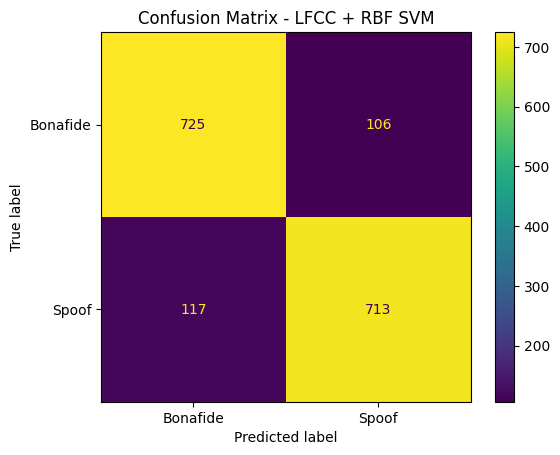

ROC-AUC: 0.9393


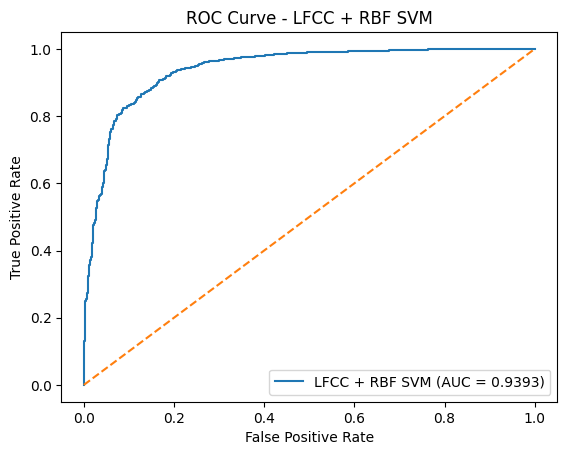

In [57]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

# =========================
# 1. Confusion Matrix
# =========================

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["bonafide", "spoof"]
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bonafide", "Spoof"]
)

disp.plot()
plt.title("Confusion Matrix - LFCC + RBF SVM")
plt.show()


# =========================
# 2. ROC-AUC
# =========================

# Get decision scores
y_test_score = best_svm.decision_function(X_test_scaled)

# Convert labels to binary:
# bonafide = 0, spoof = 1
y_test_binary = (y_test == "spoof").astype(int)

roc_auc = roc_auc_score(
    y_test_binary,
    y_test_score
)

fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    y_test_score
)

print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"LFCC + RBF SVM (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LFCC + RBF SVM")
plt.legend()
plt.show()

## Confusion Matrix and ROC-AUC

The final LFCC + RBF SVM model was evaluated using a confusion matrix and ROC-AUC on the test set.

The confusion matrix shows that 725 bona fide samples and 713 spoof samples were correctly classified. In contrast, 106 bona fide samples were incorrectly classified as spoof, while 117 spoof samples were incorrectly classified as bona fide.

The model achieved a ROC-AUC of 0.9393, indicating strong discrimination between bona fide and spoofed speech. Overall, the results demonstrate that LFCC features combined with an RBF SVM can effectively distinguish between real and spoofed speech in the test set.

## Final Results: LFCC + SVM

The LFCC features were used with Support Vector Machine (SVM) classifiers to distinguish between bona fide and spoofed speech.

Two SVM kernels were first compared on the validation set. The RBF kernel achieved better performance than the Linear kernel. Therefore, the RBF SVM was selected for hyperparameter tuning.

The best configuration was C = 10 and gamma = 0.1. This configuration was then evaluated on the independent test set.

### Hyperparameter Tuning

| Configuration | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| RBF, C=1, gamma=scale | 82.59% | 81.34% | 84.58% | 82.93% |
| **RBF, C=10, gamma=0.1** | **87.47%** | **88.49%** | **86.14%** | **87.30%** |

### Validation Performance: Linear SVM vs. RBF SVM

| Metric | Linear SVM | RBF SVM |
|---|---:|---:|
| Accuracy | 74.64% | **82.59%** |
| Precision | 73.86% | **81.34%** |
| Recall | 76.27% | **84.58%** |
| F1-score | 75.04% | **82.93%** |

### Final Test Performance

| Metric | LFCC + RBF SVM |
|---|---:|
| C | 10 |
| Gamma | 0.1 |
| Accuracy | **86.57%** |
| Precision | **87.06%** |
| Recall | **85.90%** |
| F1-score | **86.48%** |
| ROC-AUC | **93.93%** |

## Final Discussion

The LFCC + SVM experiment showed that traditional speech features can effectively distinguish between bona fide and spoofed speech. The RBF SVM consistently outperformed the Linear SVM on the validation set, achieving an F1-score of 82.93% compared with 75.04% for the Linear SVM. This indicates that the relationship between the LFCC-based features and the speech classes is better captured by a non-linear decision boundary.

Hyperparameter tuning further improved the performance of the RBF SVM. The best configuration, with C = 10 and gamma = 0.1, achieved a validation F1-score of 87.30%. When evaluated on the independent test set, the model achieved 86.57% accuracy, 87.06% precision, 85.90% recall, and 86.48% F1-score.

The confusion matrix showed that 725 bona fide and 713 spoof samples were correctly classified, while 106 bona fide samples were incorrectly classified as spoof and 117 spoof samples were incorrectly classified as bona fide. The ROC-AUC of 0.9393 indicates strong discrimination between the two classes.

Overall, the results demonstrate that LFCC features combined with an RBF SVM provide a strong traditional machine learning approach for speech deepfake detection. The relatively close validation and test performance also suggests that the selected model generalizes well to unseen samples.